# Convolución

La convolución es una operación matemática que se aplica a dos funciones para producir una tercera función. Su etimología es la siguiente

*"estado de estar enrollado sobre sí mismo; un giro, vuelta, pliegue o enrollamiento", sustantivo derivado del latín convolutus, participio pasado de convolvere "enrollar junto", formado por la unión asimilada de com ("con, junto") y volvere ("girar, rodar", de la raíz protoindoeuropea wel- (3), que significa "girar, dar vueltas"). El significado "acto de enrollar o enroscar algo junto" data de la década de 1590.*

La integral se evalúa para todos los valores del desplazamiento, produciendo la función convolución. La elección de cuál función se refleja y desplaza antes de realizar la integral no modifica el resultado de la integral (ver conmutatividad). Gráficamente, esto expresa cómo la 'forma' de una función es modificada por la otra.

$$
\begin{align}
(f * g)(t) & = \int_{-\infty}^{\infty} f(\tau) g(t - \tau) d\tau &\, & (f * g)[n] = \sum_{m=-\infty}^{\infty} f[m] g[n-m]
\end{align}
$$

## Propiedades

Conmutatividad

$$
\left(h * x\right)[n] = \left(x * h\right)[n]
$$

Asociatividad

$$
\left(h * x\right) * g = h * \left(x * g\right)
$$

Distributividad

$$
h * \left(x_1 + x_2\right) = h * x_1 + h * x_2
$$

Homogeneidad

$$
\alpha \left(h * x\right) = \left(\alpha h\right) * x
$$

Elemento Neutro

$$
x * \delta = x
$$


En la siguiente animación se muestra la convolución de una señal rectangular con una exponencial. El resultado corresponde al aŕea en cada instante.

<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/b/b9/Convolution_of_spiky_function_with_box2.gif" width="400">
</center>


Retomemos la idea de procesar una señal con un sistema LTI, es decir una convolución. Como se cumple la propiedad conmutativa, se puede pensar en el sistema como una función que se desplaza sobre la señal de entrada, o bien la señal de entrada se desplaza sobre el sistema. Por ejemplo, si el sistema es la señal cuadrada y la señal de entrada es la exponencial, vemos que el sistema es no causal y la señal de salida comienza antes que la entrada. O bien si el sistema es la exponencial y la cuadrada la entrada podemos ver como el sistema deformó la forma rectangular original por algo que tiene comportamiento exponencial.

La operación de la convolución puede explicarse geométricamente como el área del producto de dos funciones, una de las cuales se refleja y desplaza.

<center>
    <img src="../../assets/conv.png" width="300">
</center>

## Correlación cruzada

La correlación entre dos señales es una operación prima de la convolución, donde la señal que se desplaza no se refleja. Se define como:

$$
\begin{align}
R_{xy}(t) & = \int_{-\infty}^{\infty} x(\tau) y(t + \tau) d\tau &\,  & R_{xy}[n] = \sum_{m=-\infty}^{\infty} x[m] y[n+m]
\end{align}
$$

En este caso la señal de salida no es simétrica, y se puede usar para encontrar la posición de una señal en otra, o bien para encontrar la similitud entre dos señales.

El caso normalizado de la correlación cruzada se llama **coeficiente de correlación** y se define como:

$$
R_{xy}(t) = \frac{R_{xy}(t)}{\sqrt{R_{xx}(0) R_{yy}(0)}}
$$

## Auto-correlación

La auto-correlación es un caso especial de la correlación cruzada, donde ambas señales son iguales. Se define como:

$$
\begin{align}
R_{xx}(t) & = \int_{-\infty}^{\infty} x(\tau) x(t + \tau) d\tau &\,  & R_{xx}[n] = \sum_{m=-\infty}^{\infty} x[m] x[n+m]
\end{align}
$$

Como propiedades de la auto-correlación vemos que es una función par, es decir $R_{xx}(t) = R_{xx}(-t)$. Y por otro lado para *lag* 0 toma el valor máximo y es igual al valor de la energía de la señal.

$$
\begin{align}
R_{xx}(0) & = \int_{-\infty}^{\infty} |x(\tau)|^2 d\tau &\,  &
R_{xx}[0] = \sum_{n=-\infty}^{\infty} |x[n]|^2
\end{align}
$$

La versión normalizada de la auto-correlación se llama **coeficiente de auto-correlación** y se define como:    

$$
R_{xx}(t) = \frac{R_{xx}(t)}{R_{xx}(0)}
$$

## Autocorrelación de señal periódica

La auto-correlación de una señal periódica es también periódica, y su periodo es el mismo que el de la señal original. 

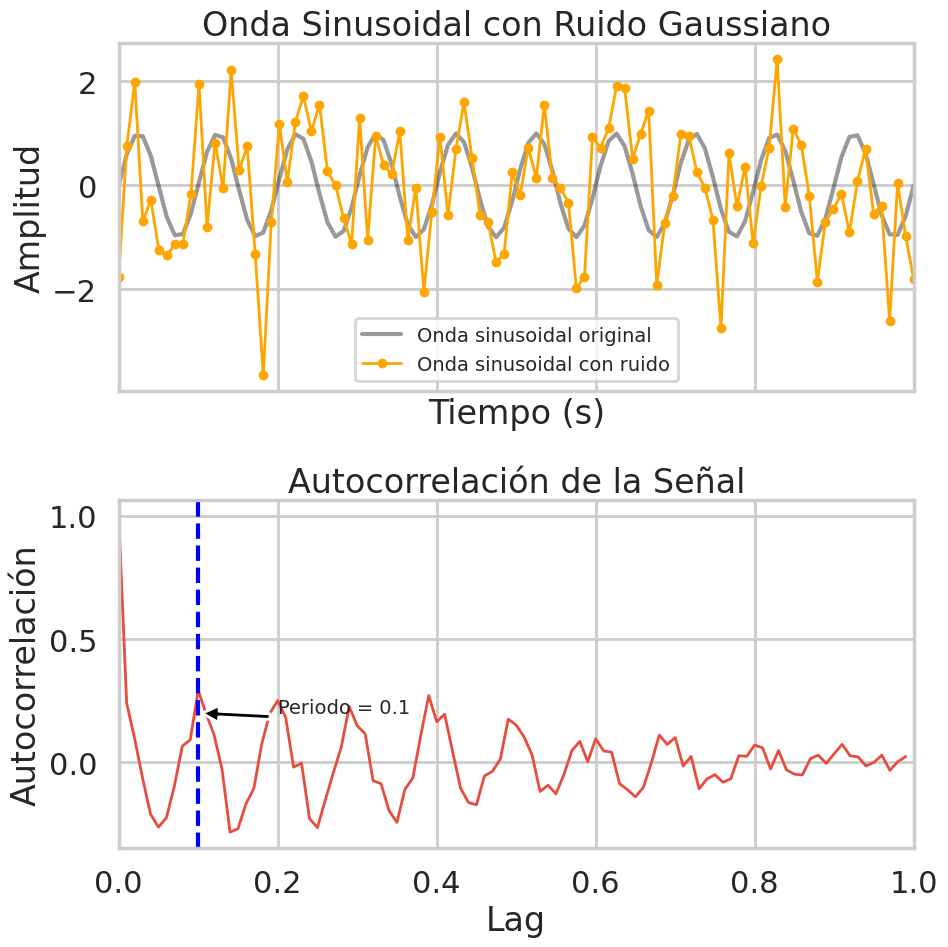

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style to poster for larger, more readable plots
sns.set_context("poster")
sns.set_style("whitegrid")

# Generar una onda sinusoidal con ruido
sr = 100
t = np.linspace(0, 1, sr)
frequency = 10  # Frecuencia de la onda sinusoidal
amplitude = 1  # Amplitud de la onda sinusoidal
phase = 0  # Desfase de la onda sinusoidal
sine_wave = amplitude * np.sin(2 * np.pi * frequency * t + phase)
# Añadir ruido gaussiano
# np.random.seed(0)  # Para reproducibilidad
# Generar ruido
noise = np.random.normal(0, 0.98, len(t))
# Añadir ruido a la onda sinusoidal
sine_wave_with_noise = sine_wave + noise

# Calcular la autocorrelación
autocorr = np.correlate(sine_wave_with_noise, sine_wave_with_noise, mode='full')
autocorr = autocorr / np.max(autocorr)  # Normalizar la autocorrelación
lags = np.arange(-len(sine_wave_with_noise) + 1, len(sine_wave_with_noise))
lags_sr = np.arange(-len(sine_wave_with_noise) + 1, len(sine_wave_with_noise)) / sr  # Lags en segundos
period = 1 / frequency   # Periodo de la onda sinusoidal

# # Graficar la onda sinusoidal con ruido
# plt.figure(figsize=(10, 4))
# plt.plot(t, sine_wave_with_noise, label='Onda sinusoidal con ruido')
# plt.xlabel('Tiempo')
# plt.ylabel('Amplitud')
# plt.title('Onda Sinusoidal con Ruido')
# plt.legend()
# plt.grid()
# plt.show()


# # Graficar la autocorrelación
# plt.figure(figsize=(10, 4))
# plt.plot(lags, autocorr, label='Autocorrelación')

# # plot vertical a periodo
# plt.axvline(x=period, color='r', linestyle='--', label='Periodo')
# plt.axvline(x=-period, color='r', linestyle='--')

# plt.annotate(f'Periodo: {period:.2f}', xy=(period, 0), xytext=(period+3, 0.5),
#              arrowprops=dict(facecolor='black', shrink=0.05),
#              fontsize=10, color='red')


# plt.xlim(0, len(sine_wave_with_noise) - 1)
# plt.xlabel('Lag')
# plt.ylabel('Autocorrelación')
# plt.title('Autocorrelación de Onda Sinusoidal con Ruido')
# plt.legend()
# plt.grid()
# plt.show()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10),sharex=True)

# Plot sine wave with noise in first subplot

ax1.plot(t, sine_wave, '-', color='black', alpha=0.4, label='Onda sinusoidal original')
ax1.plot(t, sine_wave_with_noise, '.-', color='orange', label='Onda sinusoidal con ruido', linewidth=2)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud')
ax1.set_title('Onda Sinusoidal con Ruido Gaussiano')
ax1.legend( fontsize=14)

# Plot autocorrelation in second subplot
ax2.plot(lags_sr, autocorr, color='#E74C3C', linewidth=2)
ax2.set_xlim(0, 1)
ax2.axvline(x=period, color='blue', linestyle='--', label=f'Periodo: {period:.1f}')
ax2.axvline(x=-period, color='blue', linestyle='--')
ax2.axvline(x=0, color='gray', linestyle='-', alpha=0.5)

# Add annotations
ax2.annotate(f'Periodo = {period:.1f}', xy=(period, 0.2), 
             xytext=(period*2, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=4),
             fontsize=14)

ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelación')
ax2.set_title('Autocorrelación de la Señal')

plt.tight_layout()
plt.show()


### Autocorrelación de ruido blanco

El ruido blanco es un tipo de señal aleatoria donde cada instante de la señal es independiente a los instantes anteriores. Su autorcorrelación es una delta de Dirac localizada en retraso 0.

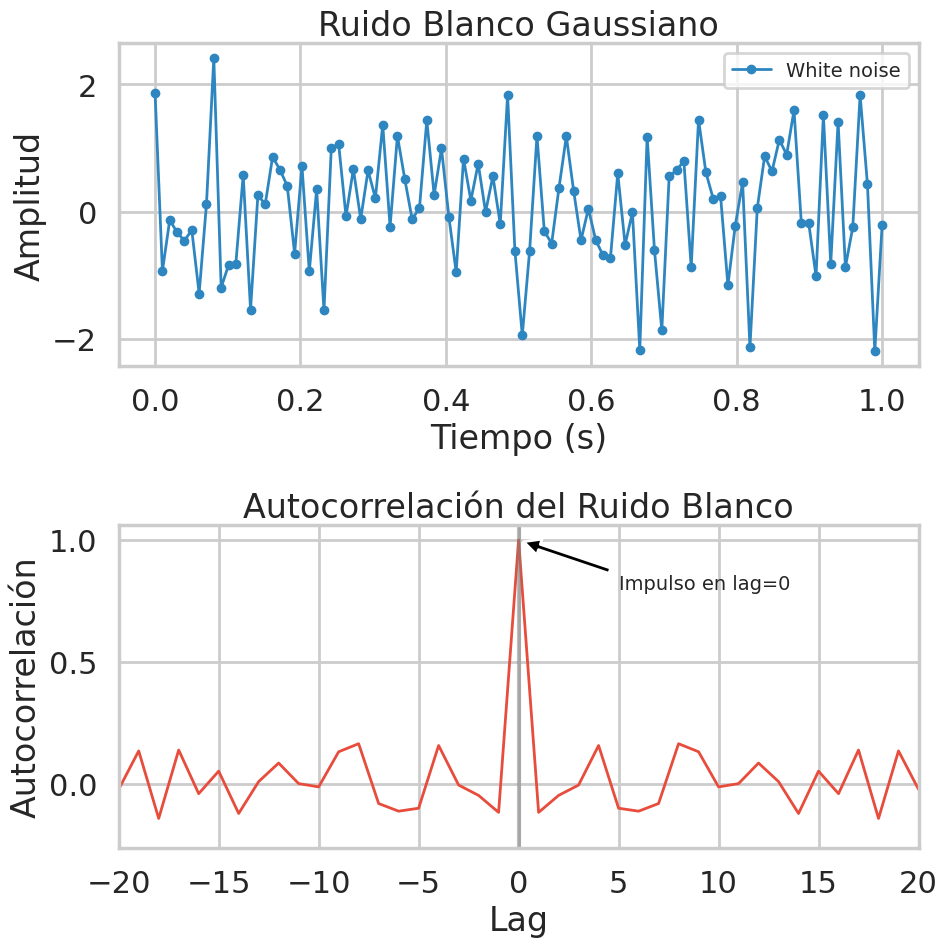

In [2]:
# Generate white noise and plot its autocorrelation
white_noise = np.random.normal(0, 1, len(t))  # Standard Gaussian white noise

# Calculate the autocorrelation of the white noise
white_noise_autocorr = np.correlate(white_noise, white_noise, mode='full')
white_noise_autocorr = white_noise_autocorr / np.sum(white_noise**2)  # Normalize the autocorrelation

# Create figure with two subplots
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot white noise in first subplot
ax1.plot(t, white_noise, '.-', color='#2E86C1', label='White noise', linewidth=2)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud')
ax1.set_title('Ruido Blanco Gaussiano')
ax1.legend(fontsize=14)

# Plot autocorrelation in second subplot
ax2.plot(lags, white_noise_autocorr, color='#E74C3C', linewidth=2)
ax2.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax2.set_xlim(-20, 20)  # Focus on central part of autocorrelation

# Add annotations
ax2.annotate('Impulso en lag=0', xy=(0, 1), 
             xytext=(5, 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=4),
             fontsize=14)

ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelación')
ax2.set_title('Autocorrelación del Ruido Blanco')

plt.tight_layout()
plt.show()

### Autocorrelación de ruido marrón

El ruido marrón es un tipo de señal aleatoria donde cada instante de la señal depende del instante anterior. Su autorcorrelación es una función exponencial decreciente.

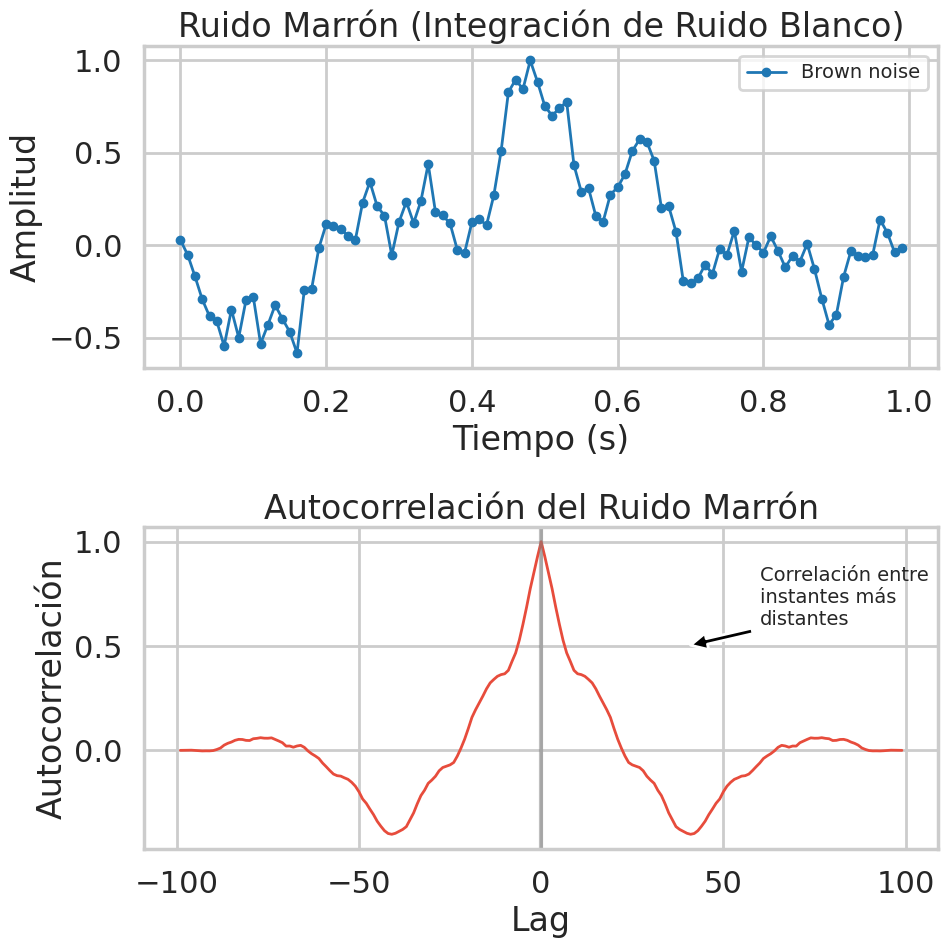

In [3]:
sr = 100
t = np.arange(0, 100)/sr

# Generate brown noise by cumulative sum of white noise and plot its autocorrelation
brown_noise = np.cumsum(np.random.normal(0, 0.1, len(t)))  # Brown noise is cumulative sum of white noise

# Normalize brown noise for better visualization
brown_noise = brown_noise / np.max(np.abs(brown_noise))

# Calculate the autocorrelation of the brown noise
brown_noise_autocorr = np.correlate(brown_noise, brown_noise, mode='full')
brown_noise_autocorr = brown_noise_autocorr / np.max(brown_noise_autocorr)  # Normalize

lags = np.arange(-len(brown_noise) + 1, len(brown_noise))

# Create figure with two subplots
fig3, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot brown noise in first subplot
ax1.plot(t, brown_noise, '.-', label='Brown noise', linewidth=2)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud')
ax1.set_title('Ruido Marrón (Integración de Ruido Blanco)')
ax1.legend(fontsize=14)

# Plot autocorrelation in second subplot
ax2.plot(lags, brown_noise_autocorr, color='#E74C3C', linewidth=2)
ax2.axvline(x=0, color='gray', linestyle='-', alpha=0.5)

# Add annotations
ax2.annotate('Correlación entre\ninstantes más\ndistantes', xy=(40, 0.5), 
             xytext=(60, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=4),
             fontsize=14)

ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelación')
ax2.set_title('Autocorrelación del Ruido Marrón')

plt.tight_layout()
plt.show()